### SVC on Linear Datasets

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
# creation of dataset

from sklearn.datasets import make_classification

In [40]:
x, y = make_classification(n_samples=1000, n_classes=2, n_features=2, n_clusters_per_class=2, n_redundant=0)

In [41]:
x

array([[-1.0659281 ,  0.14737937],
       [-2.29270558, -2.01890874],
       [-3.38660917, -2.28598891],
       ...,
       [ 0.45283806,  1.38430575],
       [ 0.48411737, -0.61122098],
       [-1.29966273, -0.62211086]], shape=(1000, 2))

In [42]:
pd.DataFrame(x)[0]

0     -1.065928
1     -2.292706
2     -3.386609
3     -0.540390
4     -1.057102
         ...   
995   -1.237036
996    1.563832
997    0.452838
998    0.484117
999   -1.299663
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

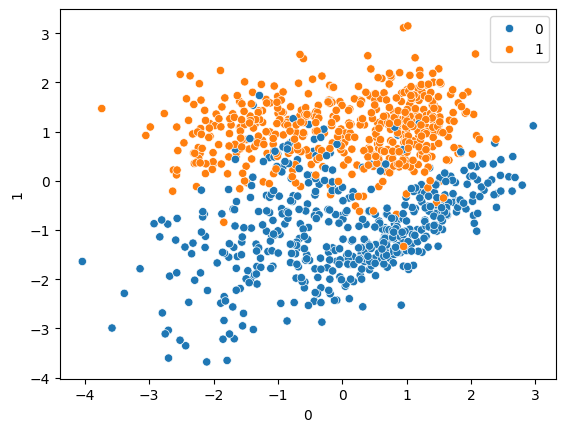

In [43]:
sns.scatterplot(x=pd.DataFrame(x)[0], y=pd.DataFrame(x)[1], hue=y)

In [44]:
# train test split

from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=10)

In [46]:
from sklearn.svm import SVC

In [47]:
svc = SVC(kernel='linear')

In [48]:
svc.fit(x_train, y_train)

SVC(kernel='linear')

In [49]:
y_pred = svc.predict(x_test)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

In [51]:
print(classification_report(y_true=y_test, y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.96      0.84      0.89       131
           1       0.84      0.96      0.90       119

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[110  21]
 [  5 114]]


In [52]:
rbf = SVC(kernel='rbf')

In [53]:
rbf.fit(x_train, y_train)

SVC()

In [54]:
y_pred = rbf.predict(x_test)

In [55]:
print(classification_report(y_true=y_test, y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91       131
           1       0.86      0.96      0.91       119

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[113  18]
 [  5 114]]


In [56]:
poly = SVC(kernel='poly')

In [57]:
poly.fit(x_test, y_test)

SVC(kernel='poly')

In [58]:
y_pred = poly.predict(x_test)

In [59]:
print(classification_report(y_true=y_test, y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       131
           1       0.89      0.80      0.84       119

    accuracy                           0.86       250
   macro avg       0.86      0.85      0.85       250
weighted avg       0.86      0.86      0.86       250

[[119  12]
 [ 24  95]]


In [60]:
sigmoid = SVC(kernel='sigmoid')

In [61]:
sigmoid.fit(x_train, y_train)

SVC(kernel='sigmoid')

In [64]:
y_pred = sigmoid.predict(x_test)

In [65]:
print(classification_report(y_true=y_test, y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       131
           1       0.78      0.86      0.82       119

    accuracy                           0.82       250
   macro avg       0.82      0.82      0.82       250
weighted avg       0.82      0.82      0.82       250

[[103  28]
 [ 17 102]]


### Hyperparameter Tuning

In [66]:
# implement grid search cv hyperparameter tuning

from sklearn.model_selection import GridSearchCV

In [67]:
params = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

In [69]:
grid = GridSearchCV(SVC(), param_grid=params, cv=5, verbose=3, refit=True)

In [70]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.907 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [71]:
grid.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [72]:
# calculate the prediction score

y_pred = grid.predict(x_test)

In [73]:
print(classification_report(y_true=y_test, y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       131
           1       0.85      0.96      0.90       119

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

[[111  20]
 [  5 114]]
